# Module 05, 06 & 07 Assignment
## Understanding the ML Problem, Exploratory Data Analysis (EDA) and Basic Preprocessing
**Dataset:** Titanic – Machine Learning from Disaster (Kaggle)

Download the **train.csv** file from Kaggle’s Titanic competition and upload it to this notebook. Rename it to `titanic.csv` or update the file name in the loading cell.
Dataset link: https://www.kaggle.com/datasets/yasserh/titanic-dataset

Total Marks: **100**

### Instructions
- This assignment covers:
  - **Module 05:** Basic ML problem framing (features, target, task type).
  - **Module 06:** Exploratory Data Analysis (EDA).
  - **Module 07:** Basic Preprocessing (handling missing values, encoding, scaling).
- Answer all questions inside this notebook using code and markdown.
- Do not delete the original question texts.
- At the end, the notebook should run from top to bottom without errors.

In [31]:
# ==============================
# Setup
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported.")

Libraries imported.


---
## Part 0: Understanding the ML Problem (Module 05) – 10 marks

### 0.1 Load the Dataset and Inspect (5 marks)
**Tasks:**
1. Load `titanic.csv` into a pandas DataFrame.
2. Show `.head()`, `.info()`, and `.describe()`.
3. Briefly look at the column names and data types.


In [32]:
# 0.1 Load the Dataset and Inspect
# TODO: Change file name if needed.

df = pd.read_csv("/content/titanic.csv")#Download the .csv file from Kaggle

print("Shape of dataset:", df.shape)
display(df.head())

print("\nInfo:")
print(df.info())

print("\nDescribe (numeric columns):")
display(df.describe())

Shape of dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Describe (numeric columns):


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 0.2 Identify Features, Target and Task Type (5 marks)
**Tasks:**
Based on the dataset:
1. Identify the **target variable** for a predictive model.
2. List at least **5 potential feature columns** you could use.
3. State whether this is a **classification** or **regression** problem, and explain **why**.

Write your answers below.


#### **Your answers**
- Target variable: Survived
- Feature columns (at least 5):  Pclass, Sex, Age, SibSp, Parch, Fare, Embarked
- Is this classification or regression, and why?:  This is a classification problem because here the target variable Survived is binary, 0 represents survived and 1 represents not survived. We have to predict between this fixed 0 and 1 rather than continuous value.

---
## Part A: Exploratory Data Analysis (EDA) – 45 marks

### 1. Initial Exploration and Cleaning Decisions (10 marks)
**Tasks:**
1. Show the number of unique values in each column.
2. Identify columns that are clearly **IDs or high-cardinality text** (for example, `PassengerId`, `Name`, `Ticket`).
3. Decide which of these columns you will **drop** for the rest of the analysis and justify in 2–3 sentences.


In [33]:
# 1. Initial Exploration and Cleaning Decisions (Task 1 is given)
print("Unique values per column:")
for col in df.columns:
    print(col, ":", df[col].nunique())

Unique values per column:
PassengerId : 891
Survived : 2
Pclass : 3
Name : 891
Sex : 2
Age : 88
SibSp : 7
Parch : 7
Ticket : 681
Fare : 248
Cabin : 147
Embarked : 3


#### Columns to drop and justification
- Columns dropped:  PassengerId, Name, Ticket, Cabin
- Justification (2–3 sentences):  PassengerId is a unique identification number and it does not have any effect on survival. Name and Ticket are high-cardinality text features and same as PassengerId these have nothing to do with survival. From the df.info() we can see Cabin has a high number of missing values which is very tough to handle.

---
### 2. Univariate Analysis (15 marks)
**Tasks:**
- Plot histograms for numeric features: `Age`, `Fare`, `SibSp`, `Parch`.
- Plot countplots for categorical features: `Sex`, `Pclass`, `Embarked`.
- Write **two to three insights** about the distributions and any obvious patterns.


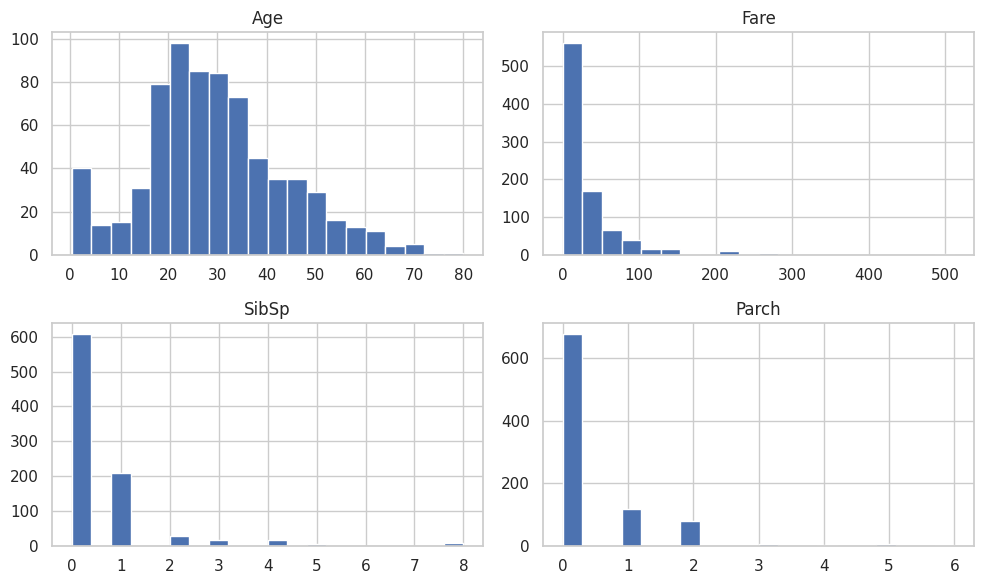

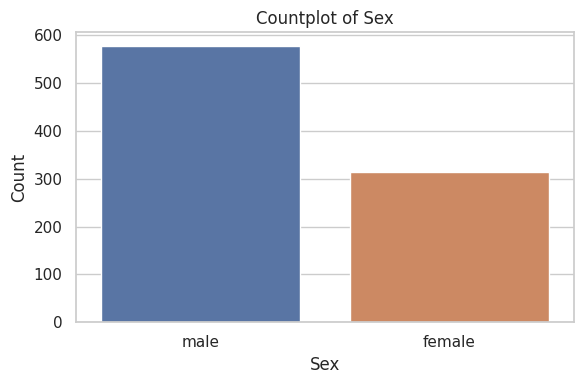

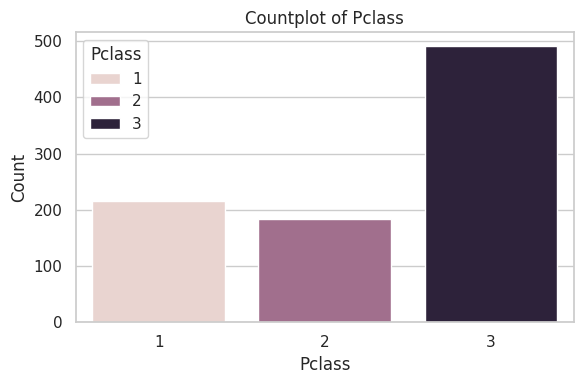

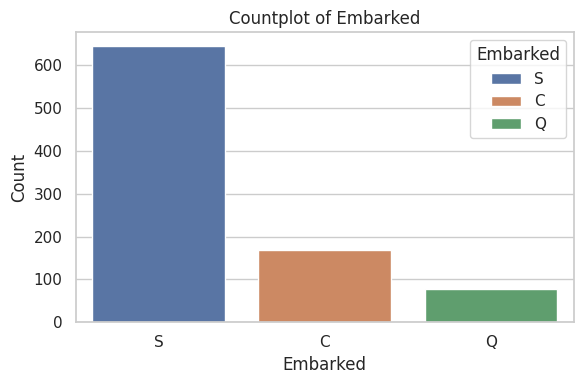

In [34]:
# 2. Univariate Analysis

numeric_cols = ["Age", "Fare", "SibSp", "Parch"]

# Histograms code is written for you
df[numeric_cols].hist(bins=20, figsize=(10, 6))
plt.tight_layout()
plt.show()

# Write Countplots code for key categorical variables [You need to complete]
print()
cat_cols = ["Sex", "Pclass", "Embarked"]
for col in cat_cols:
  plt.figure(figsize=(6, 4))
  sns.countplot(data=df, x=col, hue=col)
  plt.title(f"Countplot of {col}")
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.tight_layout()
  plt.show()
  print()

#### Write Your insights
- Insight 1:  The histogram for Age distribution looks right skewed, it means here the most of the passengers are younger, Fare is hightly right skewed, meaning most passengers paid lower fares. SibSp and Parch also showed highly right skewed pattern means most of the passengers traveled alone, fewer of the passenger were with siblings/spouses or parents/children.

- Insight 2:  From the count plot of Sex we can see there are more male passengers than the female. The Pclass count plot showed the majority of the passengers were in Pclass 3 then follwed by 1 and 2, this means a higher number of low class passengers were in the ship.

- Insight 3: The Embarked count plot shows the most common port was 'S' followed by 'C' and 'Q'.

---
### 3. Bivariate Analysis with Target (15 marks)
Use `Survived` as the target variable.

**Tasks:**
- Compute and plot a **correlation heatmap** for numeric features, including `Survived`.
- Create a **pairplot** for: `Age`, `Fare`, `SibSp`, `Parch`, and `Survived`.
- Write **two to three insights**, including which variables seem associated with survival.


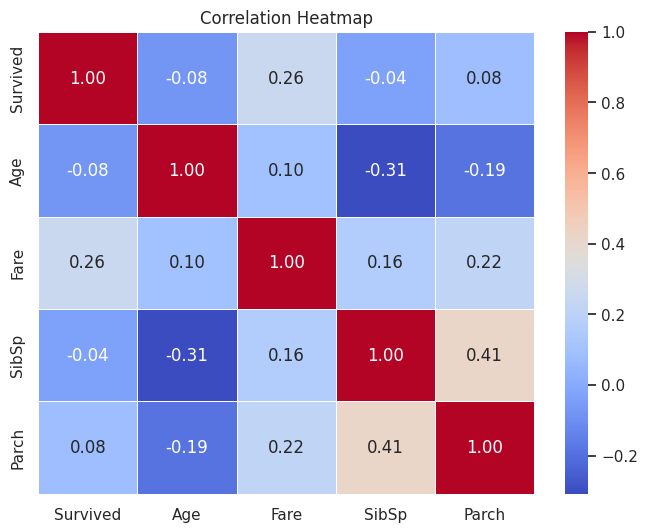

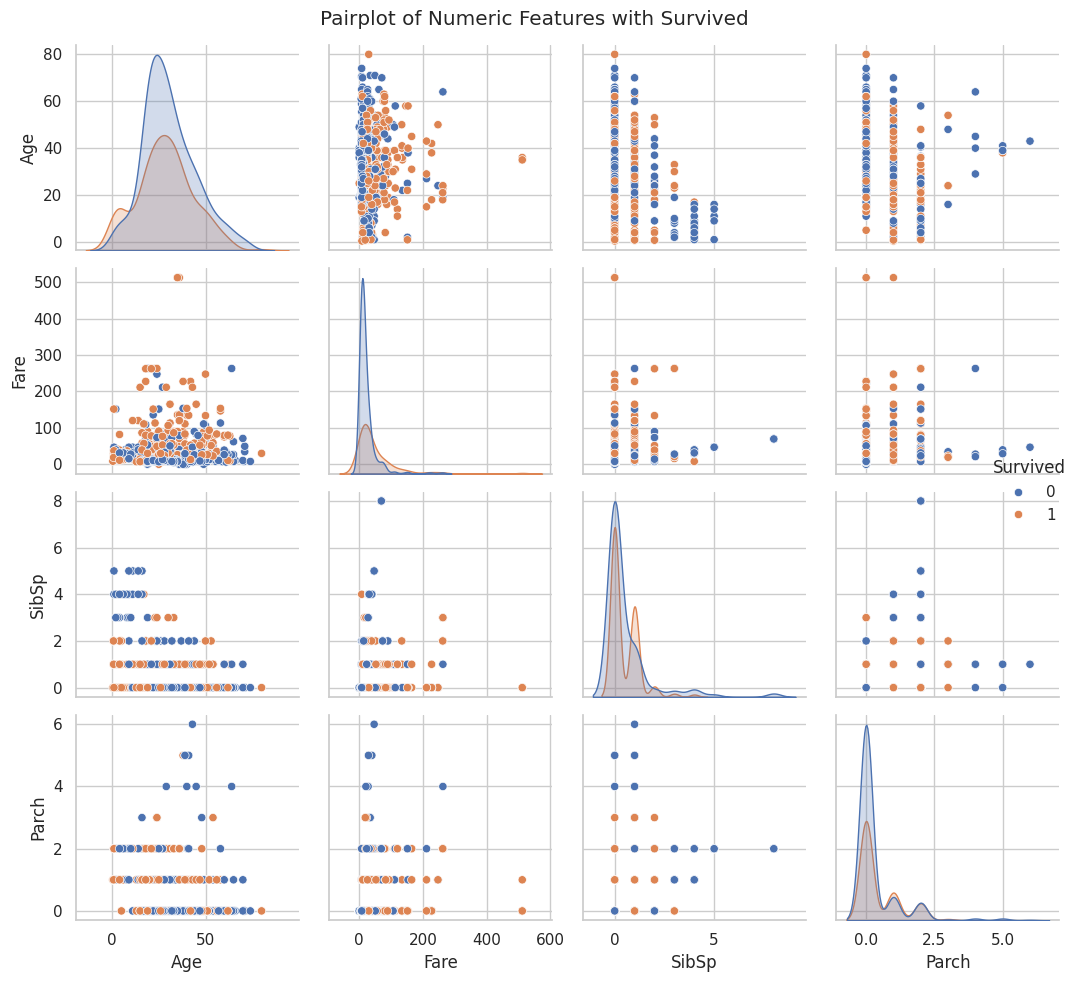

In [35]:
# 3. Bivariate Analysis with Target

num_for_corr = ["Survived", "Age", "Fare", "SibSp", "Parch"]
## Complete this code block to generate correlation heatmap and pairplot [You need to complete]

corr_matrix = df[num_for_corr].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

print()
# pairplot
sns.pairplot(df[num_for_corr], hue="Survived")
plt.suptitle("Pairplot of Numeric Features with Survived")
plt.tight_layout()
plt.show()


#### Your insights
- Insight 1:  The heatmap shows a modearte positive correlation between Fare and Survived as 0.26, means the passenger who paid high fares had a better chance of survival. The Age shows a negative weak correlation of -0.08 with Survived, means older passeneger might have lower survival rate. Similarly SibSp and Parch show very week correlation with Survived.

- Insight 2:  In the pair plot when observing the distribution of Survived, (0 survived and 1 not) across Fare we can see a clearer separation and higher density of Survived values among passengers with higher fares. For Age, there is a slight tendency for younger peoples to have survived more. Also same situation for the people who were alone survived a little bit more than the people with their family.

- Insight 3:  Based on both visualization Fare stands out as the numeric feature most strongly associated with survival. The passengers paying higher fares had a noticeably better chance of surviving.

---
### 4. Categorical vs Target Analysis (5 marks)
**Tasks:**
For each of the following categorical features: `Sex`, `Pclass`, `Embarked`:
- Plot a **bar chart** showing the proportion of passengers who survived in each category.
- Write **two short insights** about which categories have higher or lower survival chances.



Survival proportion by Sex:


Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


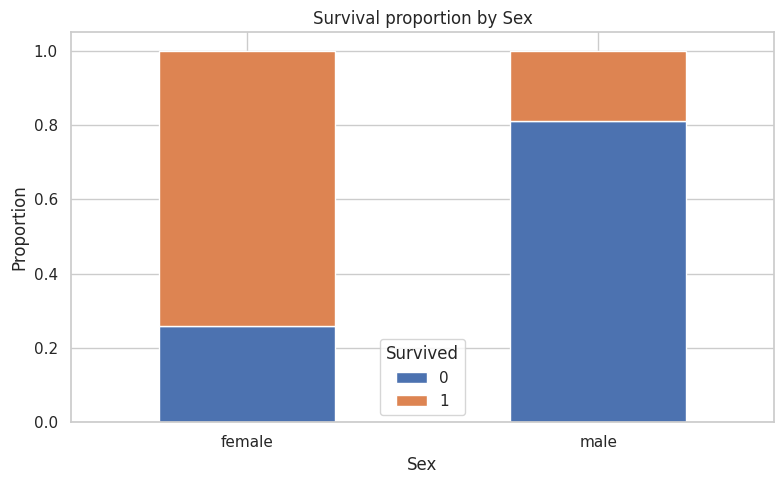


Survival proportion by Pclass:


Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


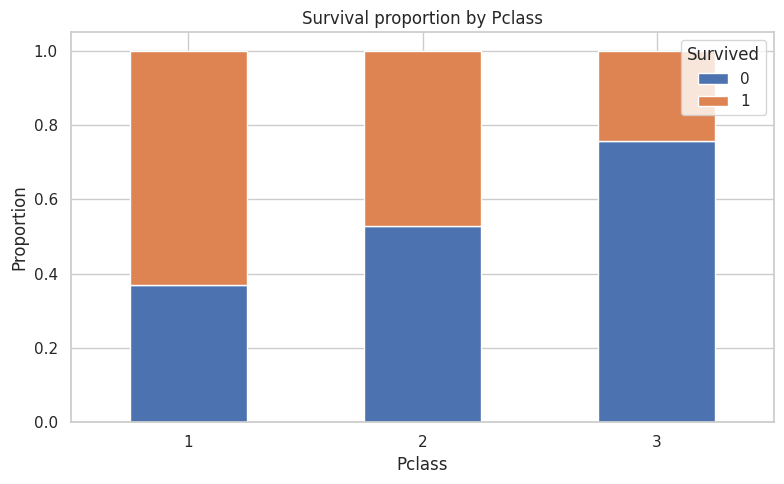


Survival proportion by Embarked:


Survived,0,1
Embarked,,
C,0.446429,0.553571
Q,0.610390,0.389610
S,0.663043,0.336957


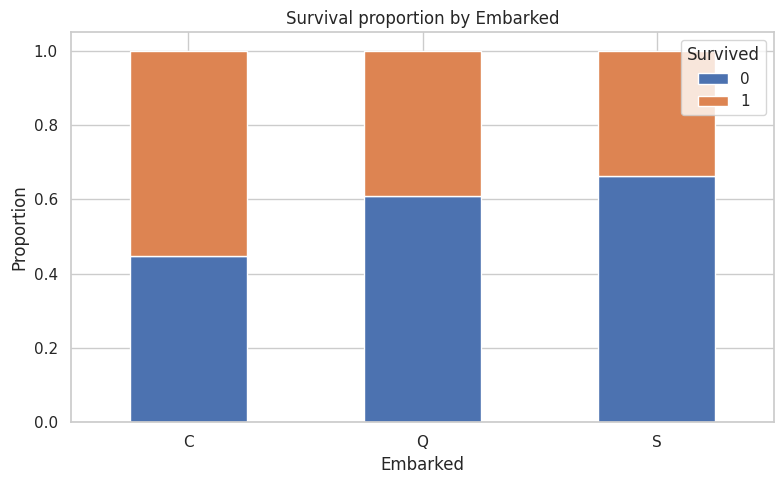

In [36]:
# 4. Categorical vs Target Analysis [Bar chart code is written for you]

cat_target_cols = ["Sex", "Pclass", "Embarked"]

for c in cat_target_cols:
    ct = pd.crosstab(df[c], df["Survived"], normalize="index")
    print(f"\nSurvival proportion by {c}:")
    display(ct)
    ct.plot(kind="bar", stacked=True)
    plt.title(f"Survival proportion by {c}")
    plt.ylabel("Proportion")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

#### Your insights
- Insight 1:  Female passengers had a significant higher survivval rate than male passengers. Also passengers in Pclass 1 had a much higher survival rate compared to Pclass 2 and especially Pclass 3, this indicating a strong correlation between social, economic status and survival.

- Insight 2:  Passengers who embarked from port C showed a higher survival rate compared to Q and S port. This means the port also played a role in survival chances, possibly due to class they occupied.

---
## Part B: Basic Data Preprocessing – 45 marks

Focus: **Handling missing values, encoding categorical variables, and scaling numeric features.**

### 5. Handling Missing Values (10 marks)
**Tasks:**
1. Show the count of missing values in each column.
2. Decide how to handle missing values for:
   - `Age` (numeric)
   - `Embarked` (categorical)
   - `Cabin` (many missing values)
3. Implement your chosen strategy in code.
4. Show missing value counts again to confirm.
5. Explain your choices in **3–4 sentences**.


In [37]:
# 5. Handling Missing Values

print("Missing values before:") #[Task 1 is done for you]
print(df.isna().sum())

# Drop Cabin (Complete this code block)
df = df.drop(columns=['Cabin'])

# Fill Age (Complete this code block)
age_median = df["Age"].median()
df["Age"] = df["Age"].fillna(age_median)

# Fill Embarked (Complete this code block)
embarked_mode = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(embarked_mode)

print("\nMissing values after handling:")
print(df.isna().sum())

Missing values before:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


#### Explanation of your strategy
- Why you dropped or kept `Cabin`:  The column Cabin has a very high number of missing values about 687 out of 891 which is probably over 70% of the data. For this high percentage, dropping the column is the most practical approach to avoid significant bias or noise.

- Why you used median/mean for `Age`:  The Age column with 177 missing values where filled with median. Because median is less sensitive to outliers compared to the mean and it also maintains the order of the data which will help preserve the distribution better.

- Why you used mode or another method for `Embarked`:  This is a categorical column with only 2 missing values. Filling with the mode is a most common and effective method for categorical features with a small number of missing values, as it preserves the overall distribution of the category.

---
### 6. Encoding Categorical Variables (15 marks)
Focus on the following categorical features:
- `Sex`
- `Embarked`
- `Pclass` (treat as categorical)

**Tasks:**
- Use `OneHotEncoder` from sklearn to encode these features.
- Keep `Survived` and the main numeric features (`Age`, `Fare`, `SibSp`, `Parch`).
- Show the shape and head of the encoded DataFrame.


In [38]:
# 6. Encoding Categorical Variables

df_enc = df.copy()

# Select features for encoding and keep important numeric ones
cat_features = ["Sex", "Embarked", "Pclass"]
numeric_features = ["Age", "Fare", "SibSp", "Parch"]
target_col = "Survived"

# One hot encode categorical variables [You need to do]
encoded_df = pd.get_dummies(df_enc[cat_features], columns=cat_features, dtype=int)

# Build final encoded DataFrame
df_model = pd.concat([
    df_enc[[target_col] + numeric_features],
    encoded_df
], axis=1)

print("Shape after encoding:", df_model.shape)
display(df_model.head())

Shape after encoding: (891, 13)


,Survived,Age,Fare,SibSp,Parch,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,0,22.0,7.2500,1,0,0,1,0,0,1,0,0,1
1,1,38.0,71.2833,1,0,1,0,1,0,0,1,0,0
2,1,26.0,7.9250,0,0,1,0,0,0,1,0,0,1
3,1,35.0,53.1000,1,0,1,0,0,0,1,1,0,0
4,0,35.0,8.0500,0,0,0,1,0,0,1,0,0,1


---
### 7. Scaling Numeric Features (15 marks)
**Tasks:**
- Use `StandardScaler` on the numeric features: `Age`, `Fare`, `SibSp`, `Parch`.
- Plot boxplots of these features **before** and **after** scaling.
- Write **two sentences** explaining how scaling changes the numeric values and why it is useful before training some ML models.


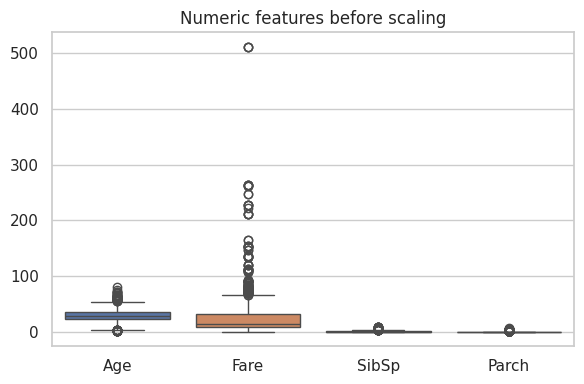

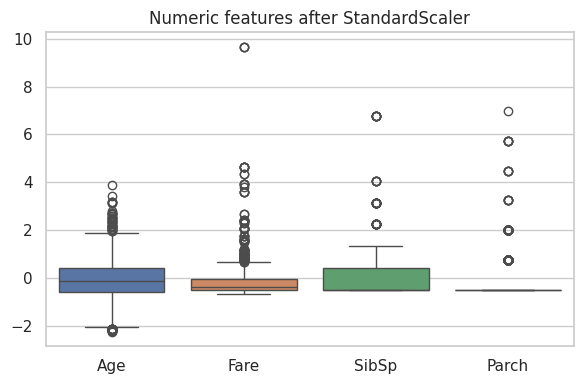

In [39]:
# 7. Scaling Numeric Features

score_cols = ["Age", "Fare", "SibSp", "Parch"]

# Boxplot before scaling
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_model[score_cols])
plt.title("Numeric features before scaling")
plt.tight_layout()
plt.show()
print()

# Apply StandardScaler [You need to do]
scaler = StandardScaler()
df_scaled = df_model.copy()
df_scaled[score_cols] = scaler.fit_transform(df_model[score_cols])

# Boxplot after scaling
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_scaled[score_cols])
plt.title("Numeric features after StandardScaler")
plt.tight_layout()
plt.show()

#### Your observations on scaling
- Sentence 1:  Scaling numeric features transforms the distributions as shown in the boxplots. Before  scaling, features like Fare showed a wide range and varying medians, while SibSp and Parch were heavily concentrated at 0, after applying StandardScaler, all features are re-centered with a mean of approximately 0 and standardized to a unit variance, visually we can also see the comparable spreads aligned around the 0 mark.
- Sentence 2:  This scaling process is crucial for many machine learning algorithms, especially those which are rely on distance calculation like k-nearest neighbors, support vector machine etc. As it prevents features with large ranges disproportionately influenncing the model's performance.  

---
### 8. Simple Feature Quality Check (5 marks)
**Tasks:**
- Show `.info()` of the final processed DataFrame (`df_scaled`).
- Confirm there are no missing values.
- Confirm that all remaining features are numeric and suitable for most ML models.
- Write **one short concluding remark** about dataset readiness.


In [40]:
# 8. Simple Feature Quality Check
print(df_scaled.info())
display(df_scaled.head())
print("\nTotal missing values in final DataFrame:", df_scaled.isna().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Age         891 non-null    float64
 2   Fare        891 non-null    float64
 3   SibSp       891 non-null    float64
 4   Parch       891 non-null    float64
 5   Sex_female  891 non-null    int64  
 6   Sex_male    891 non-null    int64  
 7   Embarked_C  891 non-null    int64  
 8   Embarked_Q  891 non-null    int64  
 9   Embarked_S  891 non-null    int64  
 10  Pclass_1    891 non-null    int64  
 11  Pclass_2    891 non-null    int64  
 12  Pclass_3    891 non-null    int64  
dtypes: float64(4), int64(9)
memory usage: 90.6 KB
None


,Survived,Age,Fare,SibSp,Parch,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,0,-0.565736,-0.502445,0.432793,-0.473674,0,1,0,0,1,0,0,1
1,1,0.663861,0.786845,0.432793,-0.473674,1,0,1,0,0,1,0,0
2,1,-0.258337,-0.488854,-0.474545,-0.473674,1,0,0,0,1,0,0,1
3,1,0.433312,0.420730,0.432793,-0.473674,1,0,0,0,1,1,0,0
4,0,0.433312,-0.486337,-0.474545,-0.473674,0,1,0,0,1,0,0,1



Total missing values in final DataFrame: 0


#### Final remark on dataset readiness
- Your remark:  The dataset has been successfully cleaned, encoded and scaled with all missing values handled and features transformed into a numerical format, making it ready for training any machine learning models.

---
## Submission
- Run all cells from top to bottom to make sure everything works.
- Set the Colab file's shareable link to ‘Anyone with the link’ and ‘View’ access, then submit it in the Phitron Assignment module's Assignment submission section.